In [1]:
import os
import sys
sys.path.append((os.path.abspath(os.path.join('..'))))

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, image_channels=1, latent_dim=16):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            # Input: n_channels x 400 x 600
            nn.Conv2d(image_channels, 32, kernel_size=4, stride=2, padding=1), # output: (32, 200, 300)
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # output: (64, 100, 150)
            nn.ReLU(),
            
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # output: (128, 50, 75)
            nn.ReLU(),
            
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # output: (256, 25, 37)
            nn.ReLU(),
            
            nn.Flatten() # output: (256 * 25 * 37)
        )
        
        # Latent space
        self.fc_mu = nn.Linear(256 * 25 * 37, self.latent_dim)
        self.fc_logvar = nn.Linear(256 * 25 * 37, self.latent_dim)
        
        # Decoder input
        self.decoder_input = nn.Linear(latent_dim, 64 * 25 * 37)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 25, 37)), # output: (64, 25, 37)
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, output_padding=(0, 1)), # output: (32, 50, 75)
            nn.Dropout2d(0.3),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1), # output: (16, 100, 150)
            nn.Dropout2d(0.3),
            nn.ReLU(),
            
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1), # output: (8, 200, 300)
            nn.Dropout2d(0.3),
            nn.ReLU(),
            
            nn.ConvTranspose2d(8, image_channels, kernel_size=4, stride=2, padding=1), # output: (1, 400, 600)
            nn.Sigmoid()
        )
        

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        h = self.decoder_input(z)
        return self.decoder(h)
    
    def forward(self, x): # x.shape = (batch_size, n_channels, height, width)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar
    
    def loss(self, recon, x, mu, logvar, beta=2.0):
        batch_size = x.size(0)

        recon_loss = nn.functional.mse_loss(recon, x, reduction='sum') / batch_size
        
        kl_loss = (-0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / batch_size

         
        total_loss = recon_loss + beta * kl_loss
        
        return total_loss, recon_loss, kl_loss

In [3]:
from torchsummary import summary

# Initialize model and display architecture summary
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = VAE().to(device)
input_size = (1, 400, 600)  
summary(model, input_size)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 200, 300]             544
              ReLU-2         [-1, 32, 200, 300]               0
            Conv2d-3         [-1, 64, 100, 150]          32,832
              ReLU-4         [-1, 64, 100, 150]               0
            Conv2d-5          [-1, 128, 50, 75]         131,200
              ReLU-6          [-1, 128, 50, 75]               0
            Conv2d-7          [-1, 256, 25, 37]         524,544
              ReLU-8          [-1, 256, 25, 37]               0
           Flatten-9               [-1, 236800]               0
           Linear-10                   [-1, 16]       3,788,816
           Linear-11                   [-1, 16]       3,788,816
           Linear-12                [-1, 59200]       1,006,400
        Unflatten-13           [-1, 64, 25, 37]               0
  ConvTranspose2d-14           [-1, 32,

In [4]:
from tqdm import tqdm
import os

def train_vae(model, train_loader, optimizer, num_epochs=10, file_name='vae', folder='checkpoints'):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model.to(device)
    model.train()
    
    os.makedirs(folder, exist_ok=True)

    for epoch in range(num_epochs):
        train_loss = 0
        model.train()

        with tqdm(train_loader, desc=f'Epoch {epoch + 1}/{num_epochs}') as pbar:
            for images, actions, rewards, dones in pbar:
                images = images.to(device)
                recon, mu, logvar = model(images)
                loss, recon_loss, kl = model.loss(recon, images, mu, logvar)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                pbar.set_postfix(loss=f"{loss.item():.4f} | mse: {recon_loss:.4f} | KL: {kl:.4f}")
                
        avg_epoch_loss = train_loss / len(train_loader)
        print(f'Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_epoch_loss:.4f}')

    # Save the trained model
    torch.save(model.state_dict(), f'{folder}/{file_name}.pth')

In [5]:
from torch.utils.data import DataLoader
from torch.optim import AdamW

from jepacartpole.datasets import CartPoleVAEDataset

LATENT_SIZE = 16
EPOCHS = 3

dataset = CartPoleVAEDataset(h5_path='../data/vae/vae_data.h5')
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=2) #, pin_memory=True, persistant_workers=True)

optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-6)

In [6]:
%%time
# train_vae(model, dataloader, optimizer, num_epochs=EPOCHS, file_name = 'vae', folder='../checkpoints')

CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 4.53 µs


# Model Diagnosis

In [7]:
import torch
from torch.utils.data import DataLoader
from jepacartpole.datasets import CartPoleVAEDataset

# load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VAE().to(device)
model.load_state_dict(torch.load('../checkpoints/vae.pth', weights_only=False, map_location=device ))

# create daloader
dataset = CartPoleVAEDataset('../data/vae/vae_data.h5')
dataloader = DataLoader(dataset, batch_size=128, num_workers=2, shuffle=True)

## 1. Reconstruction Quality

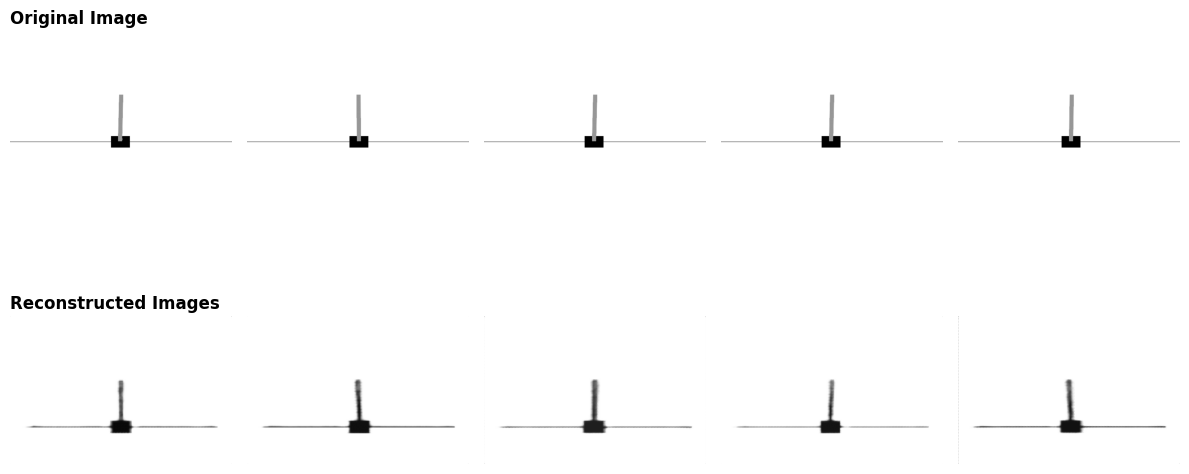

MSE: 0.0038, PSNR: 24.21 dB


In [8]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import numpy as np

def plot_images(original, reconstructed, n=4):
    fig, axes = plt.subplots(2, n, figsize=(12, 7))
    
    for i in range(n):
        axes[0, i].imshow(original[i], cmap='gray')
        axes[0, i].axis('off')
    axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold', loc='left')

    for i in range(n):
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].axis('off')
    axes[1, 0].set_title("Reconstructed Images", fontsize=12, fontweight='bold', loc='left')
    plt.tight_layout()
    plt.show()


def test_vae(model, dataset, n=3):
    # model.eval() 
    model.train()
    images = next(iter(dataset))[0].to(device)  # Get a batch of images
    
    with torch.no_grad(): 
        reconstructed, _, _ = model(images)
    indices = torch.randperm(images.size(0))[:n]  # Select random images

    reconstructed = reconstructed.cpu().squeeze().detach().numpy()
    images = images.cpu().squeeze().numpy()
    plot_images(images[indices], reconstructed[indices], n)

    mse = np.mean((images - reconstructed)**2)
    psnr = 20 * np.log10(1.0 / np.sqrt(mse))  # assuming pixel range [0,1]
    print(f"MSE: {mse:.4f}, PSNR: {psnr:.2f} dB")

test_vae(model, dataloader, n=5)

## 2. Latent Space Structure

In [ ]:
import gymnasium as gym
from gymnasium.wrappers import AddRenderObservation, TransformObservation

env = gym.make('CartPole-v1', render_mode="rgb_array")
env = AddRenderObservation(env, render_only=True)
env = TransformObservation(env, lambda obs: np.mean(obs, axis=2, keepdims=True), env.observation_space)
print(env.observation_space)

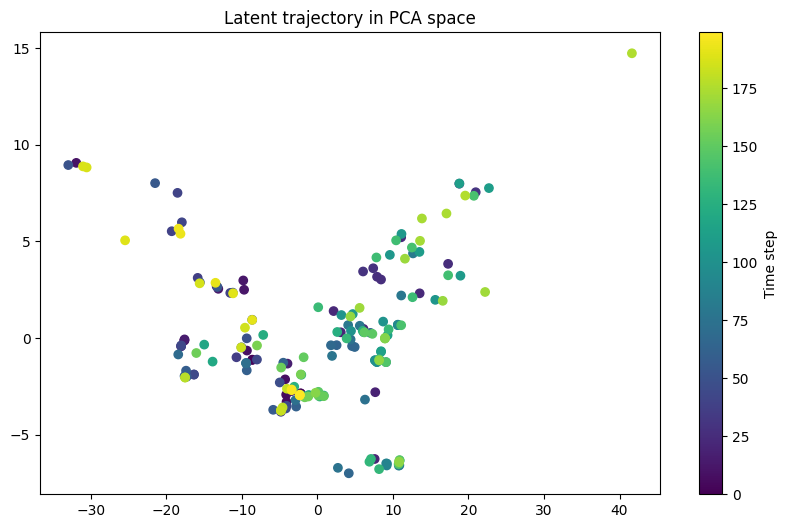

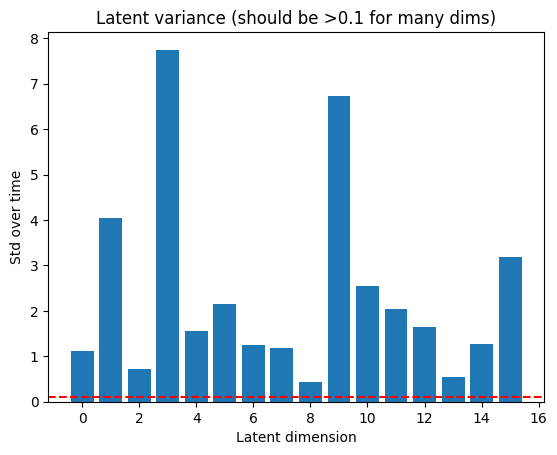

In [10]:
# Get latents for a trajectory
latents_list = []
obs, _ = env.reset()
for step in range(200):
    action = np.random.randint(0, 2)  # or a policy
    obs, reward, done, truncated, _ = env.step(action)

    with torch.no_grad():
        obs_t = torch.FloatTensor(obs).permute(2, 0, 1).unsqueeze(0).to(device)
        mu, logvar = model.encode(obs_t)
        z = model.reparameterize(mu, logvar)

    latents_list.append(z.cpu().numpy().flatten())
    if done or truncated:
        obs, _ = env.reset()
latents = np.array(latents_list)

# PCA / t-SNE visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
latents_2d = pca.fit_transform(latents)

plt.figure(figsize=(10,6))
plt.scatter(latents_2d[:,0], latents_2d[:,1], c=range(len(latents_2d)), cmap='viridis')
plt.colorbar(label='Time step')
plt.title("Latent trajectory in PCA space")
plt.show()

# Check latent variance collapse
latent_std = latents.std(axis=0)
plt.bar(range(len(latent_std)), latent_std)
plt.xlabel("Latent dimension")
plt.ylabel("Std over time")
plt.title("Latent variance (should be >0.1 for many dims)")
plt.axhline(0.1, color='r', linestyle='--')

## 3. KL Divergence vs Reconstruction Loss

In [11]:
def calculate_mean_losses():
    beta = 1

    # During evaluation
    recon_losses = []
    kl_losses = []
    total_losses = []

    print("device: " + str(device))
    pbar = tqdm(dataloader)

    with torch.no_grad():
        for images, _, _, _ in pbar:
            images = images.to(device)
            recon, mu, logvar = model(images)
            total_loss, recon_loss, kl_loss = model.loss(recon, images, mu, logvar)
            
            recon_losses.append(recon_loss.item())
            kl_losses.append(kl_loss.item())

    print(f"Avg Recon Loss: {np.mean(recon_losses):.4f}")
    print(f"Avg KL Loss: {np.mean(kl_losses):.4f}")
    print(f"KL / Recon Ratio: {np.mean(kl_losses)/np.mean(recon_losses):.2f}")

calculate_mean_losses()

device: cuda


100%|██████████| 500/500 [02:09<00:00,  3.88it/s]

Avg Recon Loss: 1066.4405
Avg KL Loss: 13.6397
KL / Recon Ratio: 0.01


## Latent Interpolation Smoothness

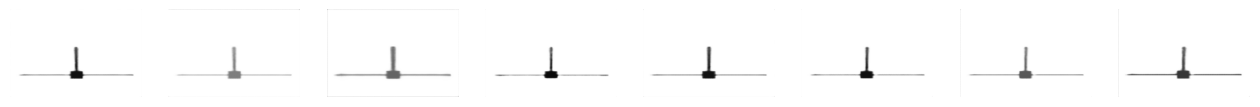

In [14]:
def interpolate(z1, z2, steps=10):
    alphas = np.linspace(0, 1, steps)
    interpolated = []
    for alpha in alphas:
        z = (1-alpha) * z1 + alpha * z2
        with torch.no_grad():
            recon = model.decode(z)
        interpolated.append(recon.cpu().numpy()[0])
    return interpolated

# Pick two very different observations
obs_batch, _, _, _ = next(iter(dataloader))
indices = np.random.choice(len(obs_batch), size=2, replace=False)

obs1, obs2 = obs_batch[indices[0]].to(device), obs_batch[indices[1]].to(device)

with torch.no_grad():
    mu1, logvar1 = model.encode(obs1.unsqueeze(0))
    mu2, logvar2 = model.encode(obs2.unsqueeze(0))

    z1 = model.reparameterize(mu1, logvar1)
    z2 = model.reparameterize(mu2, logvar2)

interp_obs = interpolate(z1, z2, steps=8)

# Visualize interpolation
fig, axes = plt.subplots(1, 8, figsize=(16, 3))
for i, img in enumerate(interp_obs):
    axes[i].imshow(img.transpose(1,2,0), cmap='gray')
    axes[i].axis('off')
plt.show()

## Posterior Collapse Test

100%|██████████| 500/500 [02:08<00:00,  3.89it/s]

Active latent dimensions (KL>0.05): 16 / 16


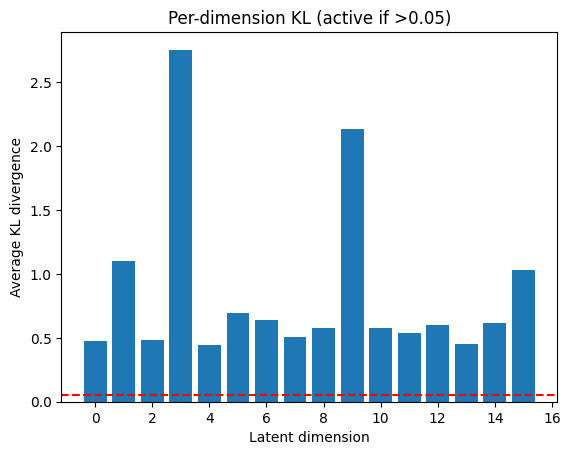

In [15]:
# Compute average KL per dimension
kl_per_dim = []

for images, _, _, _ in tqdm(dataloader):
    obs = images.to(device)
    with torch.no_grad():
        mu, logvar = model.encode(obs)
        kl_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean(dim=0)
    
    kl_per_dim.append(kl_dim.cpu().numpy())

kl_per_dim = np.mean(kl_per_dim, axis=0)
active_dims = (kl_per_dim > 0.05).sum()
print(f"Active latent dimensions (KL>0.05): {active_dims} / {len(kl_per_dim)}")

plt.bar(range(len(kl_per_dim)), kl_per_dim)
plt.xlabel("Latent dimension")
plt.ylabel("Average KL divergence")
plt.title("Per-dimension KL (active if >0.05)")
plt.axhline(0.05, color='r', linestyle='--')